# Pelatihan Model TransH Knowledge Graph Embedding
Skripsi: Sistem Rekomendasi Film Berbasis TransH Knowledge Graph Embedding

**Tujuan**:
Melatih model Knowledge Graph Embedding TransH menggunakan training split interaksi + metadata properti graf.

**Input** (dari `06_split_user/`):
- `train_triplets.tsv`, `valid_triplets.tsv`, `test_triplets.tsv`

**Output** (disimpan ke `Model_Final/`):
- `best_transh_model.pth`
- `entity2id.json` & `relation2id.json`


In [1]:
import os
import json
import math
import time
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

BASE_DIR = Path().resolve()
SPLIT_DIR = BASE_DIR / "Pipeline_Experiments/C1_FULL_CLEAN"
MODEL_DIR = BASE_DIR / "Pipeline_Experiments\C1_FULL_CLEAN\model"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_FILE = SPLIT_DIR / "train_triplets.tsv"
VALID_FILE = SPLIT_DIR / "valid_triplets.tsv"
TEST_FILE  = SPLIT_DIR / "test_triplets.tsv"

MODEL_PTH = MODEL_DIR / "best_transh_model.pth"
ENT_JSON  = MODEL_DIR / "entity2id.json"
REL_JSON  = MODEL_DIR / "relation2id.json"

# CONFIG MODEL & TRAINING
# DIMS = 192
# MARGINS = 0.5065679404997248
# LRS = 0.0006078630732783243

DIMS = 512
MARGINS = 1
LRS = 0.0004

NEG_K = 50
C = 0.001
EPOCHS = 500
BATCH_SIZE = 512
EVAL_EVERY = 2
PATIENCE_EVALS = 10
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("=" * 60)
print("  TransH Model: Pelatihan Sistem Rekomendasi")
print("=" * 60)
print(f"  Split Dir  : {SPLIT_DIR}")
print(f"  Model Dir  : {MODEL_DIR}")
print(f"  Device     : {DEVICE}")


  TransH Model: Pelatihan Sistem Rekomendasi
  Split Dir  : D:\Prototipe-Skripsi\Preprocessing\Pipeline_Experiments\C1_FULL_CLEAN
  Model Dir  : D:\Prototipe-Skripsi\Preprocessing\Pipeline_Experiments\C1_FULL_CLEAN\model
  Device     : cuda


In [2]:
def load_tsv(filepath):
    triples = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split("\t")
            if len(parts) == 3:
                triples.append(tuple(parts))
    return triples

print("Loading data splits...")
train_triples = load_tsv(TRAIN_FILE)
valid_triples = load_tsv(VALID_FILE)
test_triples = load_tsv(TEST_FILE)
all_triples = train_triples + valid_triples + test_triples

print(f"  Train: {len(train_triples):,} triplets")
print(f"  Valid: {len(valid_triples):,} triplets")
print(f"  Test : {len(test_triples):,} triplets")


Loading data splits...
  Train: 38,612 triplets
  Valid: 812 triplets
  Test : 812 triplets


In [3]:
entities, relations = set(), set()
for h, r, t in all_triples:
    entities.update([h, t])
    relations.add(r)

entity2id = {e: i for i, e in enumerate(sorted(entities))}
id2entity = {v: k for k, v in entity2id.items()}
relation2id = {r: i for i, r in enumerate(sorted(relations))}
id2relation = {v: k for k, v in relation2id.items()}

n_entities = len(entity2id)
n_relations = len(relation2id)

print(f"Entitas unik: {n_entities:,}")
print(f"Relasi unik : {n_relations}")
for rel, rid in sorted(relation2id.items(), key=lambda x: x[1]):
    print(f"  [{rid}] {rel}")

# Save JSON dictionaries
with open(ENT_JSON, "w", encoding="utf-8") as f:
    json.dump(entity2id, f, indent=4)
with open(REL_JSON, "w", encoding="utf-8") as f:
    json.dump(relation2id, f, indent=4)


Entitas unik: 3,841
Relasi unik : 8
  [0] has_actor
  [1] has_director
  [2] has_genre
  [3] has_rating
  [4] has_tag
  [5] liked
  [6] produced_in
  [7] release_year


In [4]:
def to_int(triples):
    return [(entity2id[h], relation2id[r], entity2id[t])
            for h, r, t in triples
            if h in entity2id and r in relation2id and t in entity2id]

int_train = to_int(train_triples)
int_valid = to_int(valid_triples)
int_test = to_int(test_triples)
all_triple_set = set(to_int(all_triples))

# Map specific subsets
movie_ids = [idx for ent, idx in entity2id.items() if str(ent).startswith("s") and str(ent)[1:].isdigit()]
movie_idx_map = {mid: idx for idx, mid in enumerate(movie_ids)}
user_ids = [idx for ent, idx in entity2id.items() if str(ent).startswith("U_")]
liked_rel_id = relation2id.get("liked", -1)


In [5]:
class TransH(nn.Module):
    def __init__(self, n_ent, n_rel, dim=128, margin=1.5, C=0.001):
        super().__init__()
        self.dim = dim
        self.margin = margin
        self.C = C
        self.ent_emb = nn.Embedding(n_ent, dim)
        self.rel_emb = nn.Embedding(n_rel, dim)
        self.norm_emb = nn.Embedding(n_rel, dim)
        self._init_weights()

    def _init_weights(self):
        scale = 6.0 / math.sqrt(self.dim)
        nn.init.uniform_(self.ent_emb.weight, -scale, scale)
        nn.init.uniform_(self.rel_emb.weight, -scale, scale)
        nn.init.uniform_(self.norm_emb.weight, -scale, scale)
        with torch.no_grad():
            self.ent_emb.weight.data = F.normalize(self.ent_emb.weight.data, dim=-1)
            self.norm_emb.weight.data = F.normalize(self.norm_emb.weight.data, dim=-1)

    def _project(self, e, w):
        return e - (e * w).sum(dim=-1, keepdim=True) * w

    def score(self, h_ids, r_ids, t_ids):
        h = self.ent_emb(h_ids)
        t = self.ent_emb(t_ids)
        d = self.rel_emb(r_ids)
        w = F.normalize(self.norm_emb(r_ids), dim=-1)
        h_perp = self._project(h, w)
        t_perp = self._project(t, w)
        return torch.norm(h_perp + d - t_perp, p=2, dim=-1)

    def soft_constraints(self, h_ids, r_ids, t_ids):
        d = self.rel_emb(r_ids)
        w = F.normalize(self.norm_emb(r_ids), dim=-1)
        ortho = ((d * w).sum(dim=-1) ** 2) / (torch.norm(d, dim=-1) ** 2 + 1e-8)
        h = self.ent_emb(h_ids)
        t = self.ent_emb(t_ids)
        ent_norm = (torch.clamp(torch.norm(h, dim=-1) - 1, min=0) ** 2 +
                    torch.clamp(torch.norm(t, dim=-1) - 1, min=0) ** 2)
        return ortho.mean() + ent_norm.mean()

    def forward(self, pos_h, pos_r, pos_t, neg_h, neg_r, neg_t):
        pos_score = self.score(pos_h, pos_r, pos_t)
        neg_score = self.score(neg_h, neg_r, neg_t)
        loss = torch.clamp(self.margin + pos_score - neg_score, min=0).mean()
        loss = loss + self.C * self.soft_constraints(pos_h, pos_r, pos_t)
        return loss, pos_score.mean().item(), neg_score.mean().item()

model = TransH(n_entities, n_relations, DIMS, MARGINS, C).to(DEVICE)
print("Model TransH diinisialisasi.")


Model TransH diinisialisasi.


In [6]:
rel_heads = defaultdict(set)
rel_tails = defaultdict(set)
for h, r, t in int_train:
    rel_heads[r].add(h)
    rel_tails[r].add(t)

tph = {r: len(rel_tails[r]) / max(len(rel_heads[r]), 1) for r in rel_heads}
hpt = {r: len(rel_heads[r]) / max(len(rel_tails[r]), 1) for r in rel_heads}
p_corrupt_head = {r: tph.get(r, 1.0) / (tph.get(r, 1.0) + hpt.get(r, 1.0)) for r in range(n_relations)}

def negative_sample_batch(batch, k=50):
    neg = []
    for h, r, t in batch:
        candidates = []
        attempts = 0
        while len(candidates) < k and attempts < 100:
            attempts += 1
            if random.random() < p_corrupt_head.get(r, 0.5):
                c = (random.choice(user_ids), r, t) if (r == liked_rel_id and user_ids) else (random.randrange(n_entities), r, t)
            else:
                c = (h, r, random.choice(movie_ids)) if (r == liked_rel_id and movie_ids) else (h, r, random.randrange(n_entities))
            if c not in all_triple_set: candidates.append(c)
        while len(candidates) < k:
            c = (random.randrange(n_entities), r, random.randrange(n_entities))
            if c not in all_triple_set: candidates.append(c)
        neg.extend(candidates)
    return neg

true_tails = defaultdict(set)
for h, r, t in all_triple_set:
    true_tails[(h, r)].add(t)

def evaluate_val(model, triples):
    model.eval()
    ranks = []
    movie_tensor = torch.tensor(movie_ids, dtype=torch.long, device=DEVICE)
    with torch.no_grad():
        for h, r, t in triples:
            if r != liked_rel_id or t not in movie_idx_map: continue
            h_expand = torch.full((len(movie_ids),), h, dtype=torch.long, device=DEVICE)
            r_expand = torch.full((len(movie_ids),), r, dtype=torch.long, device=DEVICE)
            scores = model.score(h_expand, r_expand, movie_tensor).cpu().numpy()
            for t2 in true_tails[(h, r)]:
                if t2 != t and t2 in movie_idx_map: scores[movie_idx_map[t2]] = 1e9
            target_idx = movie_idx_map[t]
            rank = int((scores < scores[target_idx]).sum()) + 1
            ranks.append(rank)
    if not ranks: return {"MRR": 0.0, "Hits@10": 0.0}
    ranks_arr = np.array(ranks)
    return {
        "MRR"    : float(np.mean(1.0 / ranks_arr)),
        "Hits@10": float(np.mean(ranks_arr <= 10)),
    }

def to_tensor(triples, idx):
    return torch.tensor([x[idx] for x in triples], dtype=torch.long, device=DEVICE)


In [7]:
optimizer = optim.Adam(model.parameters(), lr=LRS)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

train_losses, val_mrrs = [], []
eval_epochs = []

best_val_mrr = 0.0
best_state = None
patience = 0

print("Memulai proses training...")
for epoch in range(1, EPOCHS + 1):
    model.train()
    random.shuffle(int_train)
    epoch_loss = 0.0
    num_batches = 0

    for i in range(0, len(int_train), BATCH_SIZE):
        batch = int_train[i:i+BATCH_SIZE]
        neg = negative_sample_batch(batch, k=NEG_K)
        pos_h, pos_r, pos_t = to_tensor(batch, 0), to_tensor(batch, 1), to_tensor(batch, 2)
        neg_h, neg_r, neg_t = to_tensor(neg, 0), to_tensor(neg, 1), to_tensor(neg, 2)

        pos_h = pos_h.repeat_interleave(NEG_K)
        pos_r = pos_r.repeat_interleave(NEG_K)
        pos_t = pos_t.repeat_interleave(NEG_K)

        optimizer.zero_grad()
        loss, _, _ = model(pos_h, pos_r, pos_t, neg_h, neg_r, neg_t)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / max(num_batches, 1)
    train_losses.append(avg_loss)

    if epoch % EVAL_EVERY == 0:
        vm = evaluate_val(model, int_valid)
        mrr = vm["MRR"]
        val_mrrs.append(mrr)
        eval_epochs.append(epoch)
        scheduler.step(mrr)

        if mrr > best_val_mrr:
            best_val_mrr = mrr
            best_state = copy.deepcopy(model.state_dict())
            patience = 0
            flag = "* BEST"
        else:
            patience += 1
            flag = ""

        print(f"Epoch {epoch:3d} | Loss={avg_loss:.4f} | Val MRR={mrr:.4f} | H@10={vm['Hits@10']:.4f} | Pat={patience}/{PATIENCE_EVALS} {flag}")

        if patience >= PATIENCE_EVALS:
            print(f"Early stop triggered pada epoch ke-{epoch}.")
            break

if best_state is not None:
    model.load_state_dict(best_state)
torch.save(model.state_dict(), str(MODEL_PTH))
print("Training selesai, model terbaik disimpan.")


Memulai proses training...
Epoch   2 | Loss=0.6254 | Val MRR=0.1475 | H@10=0.2894 | Pat=0/10 * BEST
Epoch   4 | Loss=0.4691 | Val MRR=0.1589 | H@10=0.2931 | Pat=0/10 * BEST
Epoch   6 | Loss=0.4250 | Val MRR=0.1596 | H@10=0.2968 | Pat=0/10 * BEST
Epoch   8 | Loss=0.4007 | Val MRR=0.1644 | H@10=0.3042 | Pat=0/10 * BEST
Epoch  10 | Loss=0.3786 | Val MRR=0.1860 | H@10=0.3325 | Pat=0/10 * BEST
Epoch  12 | Loss=0.3561 | Val MRR=0.1976 | H@10=0.3374 | Pat=0/10 * BEST
Epoch  14 | Loss=0.3312 | Val MRR=0.2027 | H@10=0.3473 | Pat=0/10 * BEST
Epoch  16 | Loss=0.3070 | Val MRR=0.2066 | H@10=0.3571 | Pat=0/10 * BEST
Epoch  18 | Loss=0.2839 | Val MRR=0.2068 | H@10=0.3621 | Pat=0/10 * BEST
Epoch  20 | Loss=0.2625 | Val MRR=0.2089 | H@10=0.3645 | Pat=0/10 * BEST
Epoch  22 | Loss=0.2439 | Val MRR=0.2098 | H@10=0.3658 | Pat=0/10 * BEST
Epoch  24 | Loss=0.2273 | Val MRR=0.2132 | H@10=0.3756 | Pat=0/10 * BEST
Epoch  26 | Loss=0.2130 | Val MRR=0.2156 | H@10=0.3744 | Pat=0/10 * BEST
Epoch  28 | Loss=0.2007 

KeyboardInterrupt: 

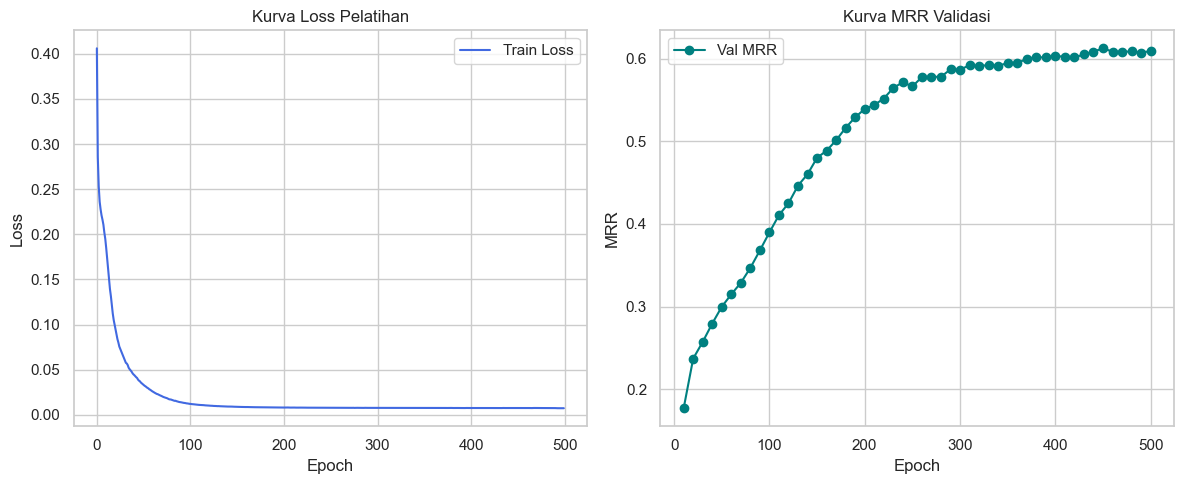

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss", color="royalblue")
plt.title("Kurva Loss Pelatihan")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(eval_epochs, val_mrrs, label="Val MRR", color="teal", marker='o')
plt.title("Kurva MRR Validasi")
plt.xlabel("Epoch")
plt.ylabel("MRR")
plt.legend()
plt.tight_layout()
plt.show()
